<div class="alert alert-info"> <b>Комментарии студентаV1:</b> Добрый день! Первый раз отправил работу по ошибке. Она тогда еще не была готова. Теперь все готово. Скорее всего стоит смотреть заново.</div>

# Проект. Исследование стартапов

- Дата: 29.11.2025

## Введение

Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. 

Трубется провести исследование на исторических данных: информациея о компаниях, объёмах и типах привлечённых инвестиций, а также с статистикой по возвратам средств.

## Цели и задачи проекта

Исследовать динамику и структуру финансирования стартапов и ответить на вопросы, для оценки инвестиционных стратегий:

-	Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
-	Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
-	Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
-	Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
-	Сравнить популярность и объёмы разных типов финансирования.
-	Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
-	Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
-	Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.


## Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### Вывод общей информации

Загружаем необходимые библиотеки и датасеты для работы:

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np



# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


In [2]:
#Создаём датафреймы

#таблица, содержащая информацию о компаниях и состоявшемся финансировании
df_main = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

#таблица, содержащая информацию об объёмах возвратов по годам и типам финансирования
df_second = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

**Выгрузим информацию `df_main`**

In [3]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [4]:

# Подсчитываем количество пропущенных значений для каждого столбца
missing_count = df_main.isna().sum()

# Вычисляем процент пропущенных значений
missing_percentage = (df_main.isna().sum() / len(df_main)) * 100

# Создаём новый датафрейм из полученных данных
missing_data = pd.DataFrame({'Кол-во пропусков': missing_count,
    'Процент пропусков': missing_percentage})

# Применяем стиль
styled_missing_data = missing_data.style.background_gradient(cmap='Blues', axis=1).format({
    'Процент пропусков': '{:,.2f}'.format})

# Отображаем результат
display(styled_missing_data)

,Кол-во пропусков,Процент пропусков
name,4857,8.95
homepage_url,8305,15.30
category_list,8817,16.24
market,8817,16.24
funding_total_usd,4856,8.94
status,6170,11.36
country_code,10129,18.66
state_code,24133,44.45
region,10129,18.66
city,10972,20.21


Из-за большого размера таблицы (40 колонок), выведем информацию из таблицы частями.

In [5]:
#Первые 20 колонок
df_main.iloc[:, :20].head(5)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0


In [6]:
#Вторые 20 колонок
df_main.iloc[:, -20:].head()

,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**<p style="color: black; background-color: orange;">Вывод по датасету `df_mail`:</p>**

- Размер датасета: 54294 строк и 40 столбцов.
- Столбцы `market` и `funding_total_usd` первым символом в названии имеют пробел. Удалим пробелы в первую очередь. Остальные названия столбцов отображает их содержимое и оформлены в удобном для работы стиле `snake_case`. 
- Во всех данные присутствуют пропуски.
- `category_list` имеет различный формат внесенной информации. Категории занесены через `|` или `+`. Тут вероятно нет ошибок, но для анализы имеет смысл привести все к единому формату.
- В `funding_total_usd`требуется убрать выделение разрядов и привести к числовому типу, так как сейчас данные типа `9,00,00,000` неудобны для анализа. Так как в данных имеются пропуски, то подойдет формат `float64`.
- В `funding_total_usd` вероятно имеются полные дубликаты в данных.
- Пропуски в `mid_funding_at` можно заменить серединой интервала между `first_funding_at` и `last_funding_at`.
- Столбцы с датами `founded_at`, `founded_month`, `founded_quarter`, `founded_year`, `first_funding_at`, `mid_funding_at`, `last_funding_at` хранятся в строковом формате `object`. Для удобства работы преобразуем в тип `datetime`.

**Комментарий:**
* Типа данных `int` (integer) предназначены для хранения целых чисел, например, 5, 10, -3 и так далее.
* Тип типа `float` используются для представления чисел с плавающей точкой, то есть чисел, имеющих дробную часть, например, 3.14, -0.5 и т. д.
* Тип данных `datetime` — это формат данных, который используется для представления даты и времени, включает в себя такие компоненты, как год, месяц, день, час, минута и секунда, и может быть представлен в различных строковых форматах.
* Тип данных `object` используется для обозначения столбцов, содержащих строковые данные или смешанные типы данных, которые не могут быть представлены численно (например, целые числа или числа с плавающей точкой).

**Выгрузим информацию `df_second`**

In [7]:
df_second.info()
#так как таблица содержит всего 15 строк, то выведем их все:
df_second.head(15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


**<p style="color: black; background-color: orange;">Вывод по датасету `df_second`:</p>**
- Размер датасета: 15 строк и 14 столбцов.
- Тип данных для столбца `year` автоматически выбран `int`, для остальных - `float64`.
- Столбец `year` сделам индеком.
- Пропуски в данных отсутствуют, явных ошибок, явных и неявных дубликатов нет.

### Промежуточный вывод


- Основная работа по предобработке данных будет вестись с первым датасетом `df_main`. Необходимо проделать работу по поиску и исправлению ошибок, проверке и выявлению явных и неявных дубликатов, изменению типа данных.
- Так как второй датасет `df_second` имеет небольшой размер, то удалось визуально оценить, что вышеперечисленные проблемы в нем отсутствуют. Сделаем столбец `year` индексом.
- Присутствуют столбцы с одинаковыми названиями в обеих таблицах: `seed`,`venture `,`equity_crowdfunding `, `undisclosed `, `convertible_note`, `debt_financing `,`angel`, `grant`, `private_equity`, `post_ipo_equity `, `post_ipo_debt`, `secondary_market`, `product_crowdfunding`. При необходимости, названия поменяем, если это потребуется для анализа.

### Предобработка данных

1. Запишем исходное количество строк `df_main` в переменную `row_count`, чтобы потом проанализировать, сколько данных было удалено и как это могло отразиться на корректности полученных результатов.


In [8]:
row_count = df_main.shape[0]

2. Удалим пробелы в названих столбцов

In [9]:
df_main.columns = df_main.columns.str.replace(' ', '')

3. Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу `float`.

In [10]:
#Удалим символ `,` и тем самым уберем выделение разрядом
df_main['funding_total_usd'] = df_main['funding_total_usd'].str.replace(',', '')

# Заменим некорректных значений на NaN
df_main['funding_total_usd'] = df_main['funding_total_usd'].replace([' -   '], np.nan)

# Преобразуем тип данных
df_main['funding_total_usd'] = df_main['funding_total_usd'].astype(float).astype(float)

3. Обработаем типы данных в столбцах, которые хранят значения даты и времени: `founded_at`, `founded_month`, `founded_quarter`, `founded_year`, `first_funding_at`, `mid_funding_at`, `last_funding_at`

In [11]:
#проверим founded_at
df_main = df_main.sort_values(by='founded_at')
print(df_main['founded_at'])

0        1636-09-08
1        1785-01-01
2        1802-07-19
3        1817-01-01
4        1826-01-01
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: founded_at, Length: 54294, dtype: object


`founded_at`оставим без изменений. Ошибки не обнаружены, но изменение типа на `datetime` приведет к потере данных, так как формат не поддерживает такие старые даты

In [12]:
#проверим founded_month
df_main = df_main.sort_values(by='founded_month')
df_main['founded_month'] = pd.to_datetime(df_main['founded_month'])
print(df_main['founded_month'])


72      1902-01-01
73      1902-01-01
74      1903-01-01
75      1905-01-01
76      1906-01-01
           ...    
54289          NaT
54290          NaT
54291          NaT
54292          NaT
54293          NaT
Name: founded_month, Length: 54294, dtype: datetime64[ns]


In [13]:
#проверим founded_quarter
df_main = df_main.sort_values(by='founded_quarter')
df_main['founded_quarter'] = pd.to_datetime(df_main['founded_quarter'])
print(df_main['founded_quarter'])

72      1902-01-01
73      1902-01-01
74      1903-01-01
75      1905-01-01
79      1906-01-01
           ...    
54289          NaT
54290          NaT
54291          NaT
54292          NaT
54293          NaT
Name: founded_quarter, Length: 54294, dtype: datetime64[ns]


C:\Users\torun\AppData\Local\Temp\ipykernel_7460\1668840705.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_main['founded_quarter'] = pd.to_datetime(df_main['founded_quarter'])


In [14]:
#проверим founded_year 
df_main = df_main.sort_values(by='founded_year')
print(df_main['founded_year'])

0        1636.0
1        1785.0
2        1802.0
3        1817.0
4        1826.0
          ...  
54289       NaN
54290       NaN
54291       NaN
54292       NaN
54293       NaN
Name: founded_year, Length: 54294, dtype: float64


In [15]:
#преобразуем founded_year в числовой формат int 
df_main['founded_year'] = pd.to_numeric(df_main['founded_year'])

In [16]:
#проверим first_funding_at  
df_main = df_main.sort_values(by='first_funding_at')
print(df_main['first_funding_at'])
print('')
df_main = df_main.sort_values(by='first_funding_at', ascending=False )
print(df_main['first_funding_at'])

37546    0001-05-14
38554    0001-07-14
38555    0001-11-14
33041    0007-05-13
2177     0011-11-14
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: first_funding_at, Length: 54294, dtype: object

49437    2014-12-31
38413    2014-12-24
34615    2014-12-20
38443    2014-12-10
49435    2014-12-02
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: first_funding_at, Length: 54294, dtype: object


Видим, что часть данных имеет аномальные значения, как пример `0011-11-14`. Преобразуем данные в столбце `first_funding_at` к типу данных `datetime`, а аномальные значения заменим на `NaT` и посчитаем, сколько стало пропусков:

In [17]:
missing_count = df_main['first_funding_at'].isna().sum()
print(f'Пропусков в first_funding_at до изменения типа данных:',missing_count)
df_main['first_funding_at'] = pd.to_datetime(df_main['first_funding_at'], errors='coerce')
missing_count = df_main['first_funding_at'].isna().sum()
print(f'Пропусков в first_funding_at после изменения типа данных:',missing_count)

Пропусков в first_funding_at до изменения типа данных: 4856
Пропусков в first_funding_at после изменения типа данных: 4866


Стало на 10 пропусков больше.

Проведем аналогичные действия с данными в `last_funding_at`:

In [18]:
missing_count = df_main['last_funding_at'].isna().sum()
print(f'Пропусков в last_funding_at до изменения типа данных:',missing_count)
df_main['last_funding_at'] = pd.to_datetime(df_main['last_funding_at'], errors='coerce')
missing_count = df_main['last_funding_at'].isna().sum()
print(f'Пропусков в last_funding_at после изменения типа данных:',missing_count)

Пропусков в last_funding_at до изменения типа данных: 4856
Пропусков в last_funding_at после изменения типа данных: 4862


Стало на 6 пропусков больше.

4. Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительную середину интервала между этими двумя датами и оценим количество оставшихся пропусков.

In [19]:
missing_count = df_main['mid_funding_at'].isna().sum()
print(f'Пропусков в mid_funding_at до заполненния средним интервалом:',missing_count)

# Вычисляем середину интервала межу first_funding_at и last_funding_at и сохраним эти значения в mid_funding_at  
df_main['interval'] = df_main['last_funding_at'] - df_main['first_funding_at']
df_main['interval'] = df_main['interval'].dt.days
df_main['interval'] = df_main['interval'] / 2
df_main['half_interval'] = df_main['first_funding_at'] + pd.to_timedelta(df_main['interval'], unit='days')
df_main['mid_funding_at'].fillna(value=df_main['half_interval'], inplace=True)
df_main['mid_funding_at'] = pd.to_datetime(df_main['mid_funding_at'])

#удалим interval и half_interval, ранее созданные столбцы, нужные для замены пропусков в mid_funding_at: 
df_main = df_main.drop(['half_interval', 'interval'], axis=1)

missing_count = df_main['mid_funding_at'].isna().sum()
print(f'Пропусков в mid_funding_at после заполненния средним интервалом:',missing_count)


Пропусков в mid_funding_at до заполненния средним интервалом: 24006
Пропусков в mid_funding_at после заполненния средним интервалом: 4864


C:\Users\torun\AppData\Local\Temp\ipykernel_7460\689828896.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_main['mid_funding_at'].fillna(value=df_main['half_interval'], inplace=True)


5. Удалим в `funding_total_usd`строки, которые не несут какой-либо информации, либо не содержат данных о финансировании.

In [20]:
# Удаляем строки с пропусками в столбце funding_total_usd
df_main = df_main.dropna(subset=['funding_total_usd'])  
 # Удаляем строки, где funding_total_usd равно 0
df_main = df_main[df_main['funding_total_usd'] != 0] 
df_main = df_main.dropna(subset=['name'])  


6. В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

In [21]:
df_second = df_second.set_index('year')

Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

7. Проверим дубликаты:

In [22]:
duplicates_count = df_main.duplicated().sum()
print(f'Количество полный дубликатов строк:',duplicates_count)

Количество полный дубликатов строк: 0


In [23]:
#Проверим наличие дубликатов по 'name', ''market','status','country_code'
#Создадим дубликаты столбцов и приведем к нижнему регистру
original_count = len(df_main)
df_main['name_dubl'] = df_main['name'].str.lower()
df_main['market_dubl'] = df_main['market'].str.lower()
df_main['status_dubl'] = df_main['status'].str.lower()
df_main['country_code_dubl'] = df_main['country_code'].str.lower()
#найдем дубликаты и исключим их
df_main = df_main.drop_duplicates(['name_dubl', 'market_dubl','status_dubl','country_code_dubl'])

#посчитаем, сколько дубликатов было найдено и исключено
duplicates_count = original_count - len(df_main)
print(f"Было найдено {duplicates_count} дубликата(ов)")

#удалим дубликаты стоблцов, которые были нужны для проверки дубликатов: 
df_main = df_main.drop(['name_dubl', 'market_dubl', 'status_dubl','country_code_dubl'], axis=1)

Было найдено 4 дубликата(ов)


8. Проверим на неявные дубликаны значения в `market`:

In [24]:
# Подсчитываем количество уникальных значений
count_market = df_main['market'].value_counts()
# Сортируем по алфавиту
count_market = count_market.sort_index()
print(count_market)


market
 3D                1
 3D                1
 3D Printing       3
 Ad Targeting      1
 Advertising      28
                  ..
Web Hosting        1
Web Tools          1
Web Tools          1
Wireless           1
iPhone             1
Name: count, Length: 848, dtype: int64


Видим, что 848 уникальных значений. Видно, что часть элементов дублируется. Чтобы решить проблему с неявныеми дуликатами, удалим лишние пробелы и приведем все значения в `market` к нижнему регистру.

In [25]:
#удалим пробелы в начале и в конце строки
df_main['market'] = df_main['market'].str.strip()
df_main['market'] = df_main['market'].str.lower()

#Посмотрим, сколько теперь осталось уникальных значений:
count_market = df_main['market'].value_counts()
# Сортируем по алфавиту
count_market = count_market.sort_index()
print(count_market)


market
3d                         2
3d printing                3
ad targeting               1
advertising             1107
advertising networks       1
                        ... 
weddings                   2
wholesale                  2
wine and spirits           2
wireless                  64
women                      1
Name: count, Length: 394, dtype: int64


В итоге вместе 848 уникальных значений, теперь 394 элемента. 

Оценим полноту данных и сделаем предварительный вывод о том, достаточно ли данных для решения задач проекта. 

In [26]:
# Создадим новый столбец и присвоим каждой компании индивидуальный номер (ключ). Номер возьмем из столбца с индексом.
# Будет полезным для аналитической работы проекта.
df_main['key'] = df_main.index

In [27]:
#Посчитаем количество отфильтрованных данных, после удаления.
print(f"Количество строк до удаления: {row_count}")
row_count_1= row_count -df_main.shape[0]
print(f"количество удалённых строк: {row_count_1} или {row_count_1 / row_count * 100:.2f}%")
print(f"Количество строк после удаления: {df_main.shape[0]}")
print('')
df_main.info()

Количество строк до удаления: 54294
количество удалённых строк: 13392 или 24.67%
Количество строк после удаления: 40902

<class 'pandas.core.frame.DataFrame'>
Index: 40902 entries, 49437 to 33041
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40902 non-null  object        
 1   homepage_url          38588 non-null  object        
 2   category_list         38399 non-null  object        
 3   market                38399 non-null  object        
 4   funding_total_usd     40902 non-null  float64       
 5   status                39797 non-null  object        
 6   country_code          37084 non-null  object        
 7   state_code            25616 non-null  object        
 8   region                37084 non-null  object        
 9   city                  36398 non-null  object        
 10  funding_rounds        40902 non-null  float64       
 11  participants

**<p style="color: black; background-color: orange;">Вывод по предобработке данных:</p>**


**Датасет df_main**
- Изначально, в датасете df_main было 54294 строк. После преобработки стало 40902, то есть было исключено 13392 строк или 24.67%.
- ИЗ 13392 строк было удалено 4 дублика. Остальные строки это пропуски и 0, которые не влияют на цели и задачи проекта.
- В названиях столбцов `market` и `funding_total_usd` были ужалены пробелы в названиях.
- В `funding_total_usd` былио убрано выделение разрядов и данные были приведены к числовому типу.
- Пропуски в `mid_funding_at` были заменены на середину интервала между `first_funding_at` и `last_funding_at`.
- Тип данных для столбцов, которые хранят значения даты и времени, был приведен к тип `datetime`, где это было возможно.
- В `market`была решена проблема с неявными дубликатами.
- Добавлен новый столбец `key`, содержащий индивидулаьный номер для каждой компании.


**Датасет df_second**
- Пропуски в данных отсутствуют, явных ошибок, явных и неявных дубликатов нет.
- Столбец `year` сделаy индеком.


**Основная работа по предобработке была проведена с датасетом `df_main`. Был проведен поиск и исправление ошибок, проверены и выявлены дубликаты, типы данных приведены удобным для работы. Никакие критичеси важные данные не были потеряны и можно присутпить к целям и задачам работы.**

### Группы по срокам финансирования

Разделим все компании на три группы:

- Единичное финансирование — был всего один раунд финансирования.
- Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
- Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:
- По количеству компаний: Покажем, какой процент от общего числа компаний относится к каждой из трёх групп.
- По объёму инвестиций: Отобразим, какую долю от общего объёма привлечённых средств получила каждая группа.

In [28]:
def Financing_period(row):
    if row['funding_rounds'] == 1:
        return "Единичное финансирование"
    elif (row['mid_funding_at'] - row['first_funding_at']).days <= 365:
        return "Срок финансирования до года"
    elif (row['mid_funding_at'] - row['first_funding_at']).days > 365:
        return "Срок финансирования более года"

df_main['financing_period'] = df_main.apply(Financing_period, axis=1)


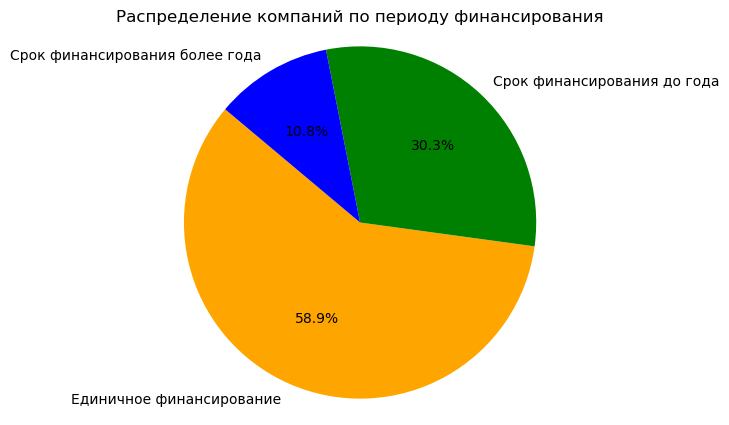

In [29]:
# Подсчитываем количество уникальных значений для каждой категории
unique_counts = df_main['financing_period'].value_counts()

# Строим круговую диаграмму
plt.figure(figsize=(5, 5))
plt.pie(unique_counts, labels=unique_counts.index, autopct='%1.1f%%', startangle=140, colors=['orange', 'green', 'blue'])
plt.axis('equal') 
plt.title('Распределение компаний по периоду финансирования')

plt.show()


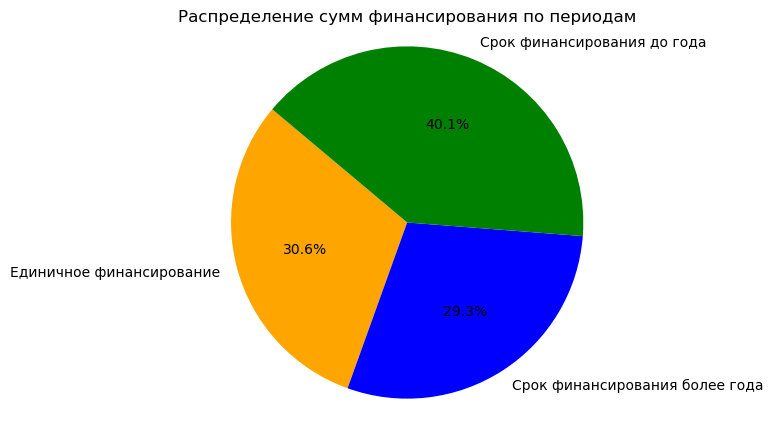

In [30]:
# Группируем данные по периоду финансирования и суммируем значения funding_total_usd
summary = df_main.groupby('financing_period')['funding_total_usd'].sum()

# Строим круговую диаграмму
plt.figure(figsize=(5, 5))
plt.pie(summary, labels=summary.index, autopct='%1.1f%%', startangle=140, colors=['orange', 'blue','green'])
plt.axis('equal')
plt.title('Распределение сумм финансирования по периодам')

plt.show()

**<p style="color: black; background-color: orange;">Вывод по группам сроков финансирования:</p>**
- 58,9% всех компаний, это компании с единичным финансированием, при этом они получили примерно только 30% об общего объема финансирования.
- Только 10,8% всех компаний финансировались более 1 года, получив 30% всех финансовых средств.
- Больше всего финансирования (40%) получили компании с финансированием до 1 года.

### Выделение средних и нишевых сегментов рынка

На основе информации о сегменте рынка компаний в столбце `market` рассчитаем, как часто в датасете встречается каждый из сегментов:
- Сегменты, к которым относится более 120 компаний, отнесем к массовым.
- Сегменты, в которые входит от 35 до 120 включительно, отнесем к средним
- Сегменты до 35 компаний отнесем к нишевым.
- Рассчитаем, сколько сегментов попадает в каждую из категорий.
- Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [31]:
def segment(x):
    if x > 120:
        return 'Массовый сегмент'
    elif 35 < x <= 120:
        return 'Средний сегмент'
    else:
        return 'Нишевый сегмент'
    
df_market = df_main['market'].value_counts()
df_market = df_market.sort_values(ascending=False)

df_market = df_market.reset_index()
df_market.columns = ['Сегмент', 'Кол-во компаний']

df_market['Категория'] = df_market['Кол-во компаний'].apply(segment)

display(df_market)


,Сегмент,Кол-во компаний,Категория
0,software,4812,Массовый сегмент
1,biotechnology,3589,Массовый сегмент
2,mobile,2344,Массовый сегмент
3,e-commerce,1866,Массовый сегмент
4,curated web,1693,Массовый сегмент
...,...,...,...
389,flash storage,1,Нишевый сегмент
390,classifieds,1,Нишевый сегмент
391,task management,1,Нишевый сегмент
392,web design,1,Нишевый сегмент


In [32]:
#Посчитаем, сколько мегментов попадет в каждую категорию
df_market_1 = df_main['market'].value_counts()
mass_segment = 0
middle_segment = 0
niche_segment = 0

for i in df_market_1:
    if i > 120:
        mass_segment=mass_segment+1
    elif 35 < i <= 120:
        middle_segment=middle_segment+1
    else:
        niche_segment=niche_segment+1

print("Массовый сегмент:", mass_segment)
print("Средний сегмент:", middle_segment)
print("Нишевый сегмент:", niche_segment)


Массовый сегмент: 48
Средний сегмент: 57
Нишевый сегмент: 289


Количество компаний по сегментам:
Категория
Массовый сегмент    33728
Нишевый сегмент       830
Средний сегмент      3841
Name: Кол-во компаний, dtype: int64


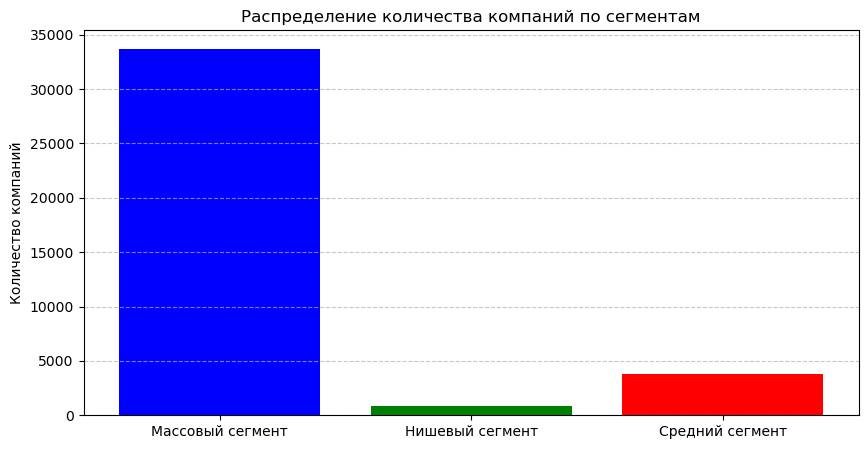

In [33]:
# Группируем данные по категориям
grouped = df_market.groupby('Категория')['Кол-во компаний'].sum()
print('Количество компаний по сегментам:')
print(grouped)

# Построение графика
plt.figure(figsize=(10, 5))
bars = plt.bar(grouped.index, grouped.values, color=['blue', 'green', 'red'])
plt.title('Распределение количества компаний по сегментам')
plt.xlabel('')
plt.ylabel('Количество компаний')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [34]:
df_segment = df_market.copy()
df_main = df_main.merge(df_segment[['Сегмент', 'Категория']], left_on='market', right_on='Сегмент', how='left')
# Удаление столбца 'Категория'
df_main = df_main.drop('Сегмент', axis=1)

# Переименование столбца 'Сегмент' в 'SIG'
df_main = df_main.rename(columns={'Категория': 'segment'})

In [35]:
#Проверим, что все работает как надо
df_main[['name','market','segment']].head()

,name,market,segment
0,Logovers,startups,Массовый сегмент
1,Arena Online,social games,Нишевый сегмент
2,DigiByte,NaN,NaN
3,Helpling,consumers,Средний сегмент
4,KINGLET,NaN,NaN


In [36]:
def change_market(row):
    if row['segment'] == 'Нишевый сегмент':
        return 'niche'
    elif row['segment'] == 'Средний сегмент':
        return 'mid'
    else:
        return row['market']

df_main['market'] = df_main.apply(change_market, axis=1)
#Проверим, что все работает как надо
df_main[['name','market','segment']].head()

,name,market,segment
0,Logovers,startups,Массовый сегмент
1,Arena Online,niche,Нишевый сегмент
2,DigiByte,NaN,NaN
3,Helpling,mid,Средний сегмент
4,KINGLET,NaN,NaN


**<p style="color: black; background-color: orange;">Вывод по выделению средних и нишевых сегментов рынка:</p>**
- На основе информации о сегменте рынка компаний в столбце `market` рассчитали, как часто в датасете встречается: `Массовый сегмент`,  `Средний сегмент`, `Нишевый сегмент`.
- Рассчитаем, сколько сегментов попадает в каждую из категорий.
- Построили график распределения количества компаний в сегментах.
- Оставили в столбце market только массовые сегменты. Для остальных сегментов заменили значения на заглушки — niche для нишевых и mid для средних.

**По итогу видно, что финансирование чаще получают компании из `Массовый сегмент`.**

## Работа с выбросами и анализ

### Анализируем и помечаем выбросы в каждом из сегментов

- Проанализируем периоды и размеры средств, который предоставлялся компаниям
- По данным из `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. 
- Найдем интервал, в котором лежат типичные значения финансирования.

In [37]:
#Посмотрим статистику по столбцу funding_total_usd
print(df_main['funding_total_usd'].describe())

count    4.090200e+04
mean     1.591404e+07
std      1.686890e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64


Среднее значение 159 140 400,00, максимальное 3 007 950 000 000. Так как в основном будем иметь дело с сотнями миллионов и с миллиардами, то создадим новый столбец на основе `funding_total_usd`, разделим все значения на 1 000 000.

In [38]:
df_main['funding_total_usd_mln'] = df_main['funding_total_usd'] / 1000000
#Посмотрим статистику по столбцу новому столбцу funding_total_usd_mln
print(df_main['funding_total_usd_mln'].describe())

count    40902.000000
mean        15.914040
std        168.689047
min          0.000001
25%          0.350000
50%          2.000000
75%         10.000000
max      30079.503000
Name: funding_total_usd_mln, dtype: float64


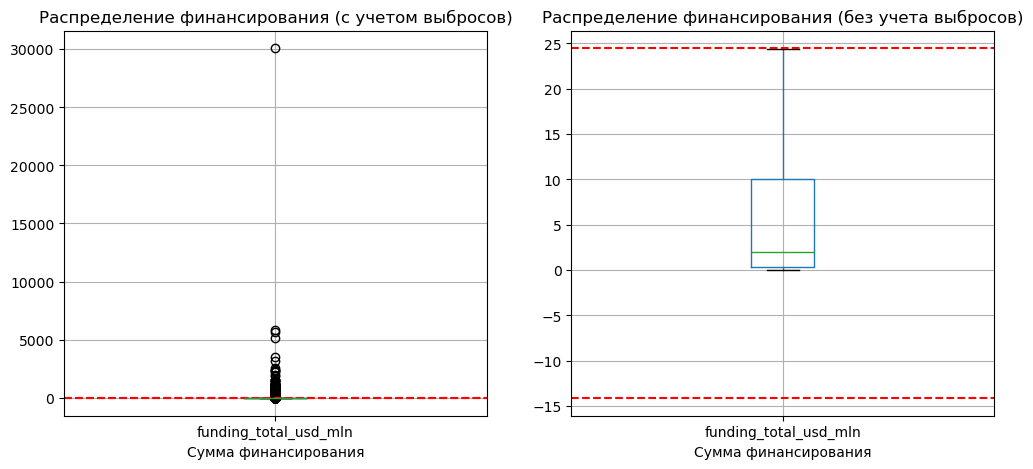

IQR= 9.65


In [39]:
# Рассчитываем IQR
Q1 = df_main['funding_total_usd_mln'].quantile(0.25)
Q3 = df_main['funding_total_usd_mln'].quantile(0.75)
IQR = Q3 - Q1

# Определяем пороги для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Первый боксплот с учетом выбросов
boxplot1 = df_main.boxplot(column='funding_total_usd_mln', ax=ax1)
ax1.set_title('Распределение финансирования (с учетом выбросов)')
ax1.set_xlabel('Сумма финансирования')

# Добавляем линии для порогов выбросов
ax1.hlines(lower_bound, xmin=0.5, xmax=1.5, colors='r', linestyles='dashed')
ax1.hlines(upper_bound, xmin=0.5, xmax=1.5, colors='r', linestyles='dashed')

# Второй боксплот без выбросов без учета выбросов
boxplot2 = df_main.boxplot(column='funding_total_usd_mln', showfliers=False, ax=ax2)
ax2.set_title('Распределение финансирования (без учета выбросов)')
ax2.set_xlabel('Сумма финансирования')

# Добавляем линии для порогов выбросов
ax2.hlines(lower_bound, xmin=0.5, xmax=1.5, colors='r', linestyles='dashed')
ax2.hlines(upper_bound, xmin=0.5, xmax=1.5, colors='r', linestyles='dashed')

plt.show()
print(f'IQR=',IQR)

**Интепретация результатов:**
- Ящик (IQR) Представляет межквартильный размах, который включает 50% центральных данных, то есть данные между 0,25 и 0.75 квартилями.
- Ширина ящика показывает разброс средних значений финансирования. Чем шире ящик, тем больше разброс в средних значениях финансирования стартапов. В нашем случае разброс от 0,35 млн до 10 млн. 
- Медиана (линия внутри ящика) показывает среднее значение финансирования среди стартапов. Если линия смещена ближе к одному из краев ящика, это может указывать на асимметрию в данных. В нашем случае мадиана равна 2 млн
- Усы отображают диапазон значений, исключая выбросы. Длина усов может давать представление о том, насколько широко разбросаны данные. "Наши усы" длинные, и это указывает на большой диапазон финансирования, включая как очень низкие, так и очень высокие значения. В нашем случае усы до 25 млн.
- Выбросы (точки за пределами усов) - значения, которые значительно отличаются от других данных. В контексте финансирования стартапов выбросы могут указывать на особенно успешные или неудачные проекты с точки зрения привлеченного финансирования.
- Красным пунктиром обозначены границы 1.5 * IQR.

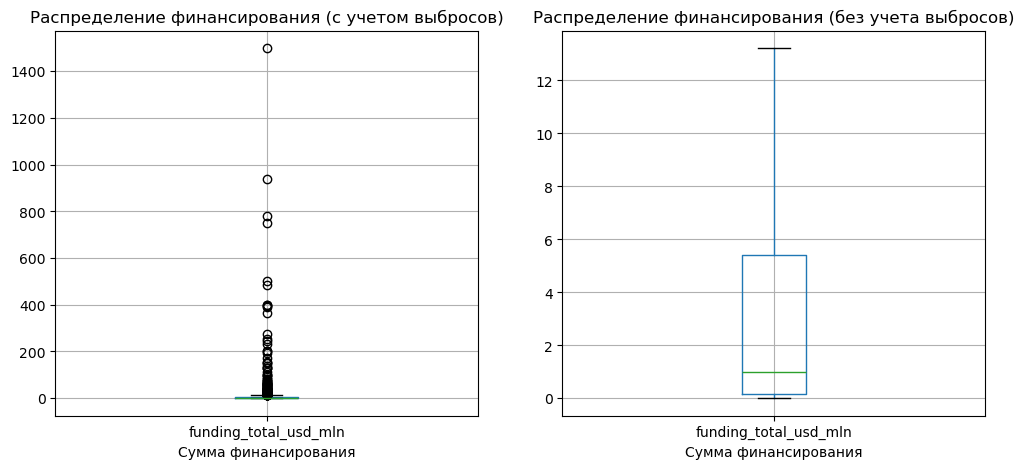

In [40]:
#Построим ящик с усами для нишевого сегмента
df_niche = df_main[df_main['market'] == 'niche']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Первый боксплот с учетом выбросов
boxplot1 = df_niche.boxplot(column='funding_total_usd_mln', ax=ax1)
ax1.set_title('Распределение финансирования (с учетом выбросов)')
ax1.set_xlabel('Сумма финансирования')

# Второй боксплот без выбросов без учета выбросов
boxplot2 = df_niche.boxplot(column='funding_total_usd_mln', showfliers=False, ax=ax2)
ax2.set_title('Распределение финансирования (без учета выбросов)')
ax2.set_xlabel('Сумма финансирования')

plt.show()

**Интепретация результатов для нишевого сегмента:**
- Разброс средних значений финансирования от 0,1 млн до 5,5 млн. 
- Медиана (линия внутри ящика) смещена ближе к нижнему краю, что указывать на асимметрию в данных. Мадиана равна 1 млн.
- Усы длинные, и это указывает на большой диапазон финансирования, включая как очень низкие, так и очень высокие значения. До 13,5 млн.
- Выбросы (точки за пределами усов) - значения, которые значительно отличаются от других данных и могут быть более 1300 млн.

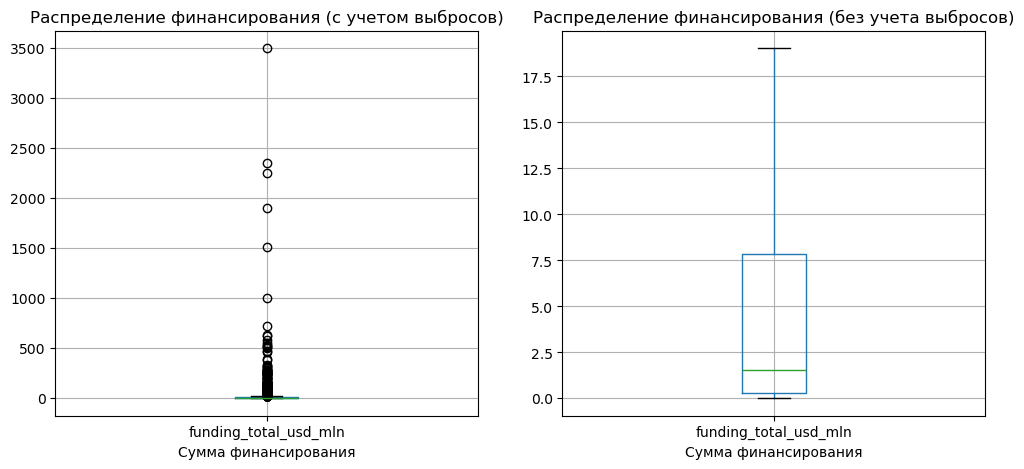

In [41]:
#Построим ящик с усами для среднего сегмента
df_mid = df_main[df_main['market'] == 'mid']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Первый боксплот с учетом выбросов
boxplot1 = df_mid.boxplot(column='funding_total_usd_mln', ax=ax1)
ax1.set_title('Распределение финансирования (с учетом выбросов)')
ax1.set_xlabel('Сумма финансирования')

# Второй боксплот без выбросов без учета выбросов
boxplot2 = df_mid.boxplot(column='funding_total_usd_mln', showfliers=False, ax=ax2)
ax2.set_title('Распределение финансирования (без учета выбросов)')
ax2.set_xlabel('Сумма финансирования')

plt.show()

**Интепретация результатов для среднего сегмента:**
- Разброс средних значений финансирования от 0,1 млн до 7,6 млн. 
- Медиана (линия внутри ящика) смещена ближе к нижнему краю, что указывать на асимметрию в данных. Мадиана равна 1,8 млн.
- Усы длинные, и это указывает на большой диапазон финансирования, включая как очень низкие, так и очень высокие значения. До 18 млн.
- Выбросы (точки за пределами усов) - значения, которые значительно отличаются от других данных и могут быть более 18,9 млн.

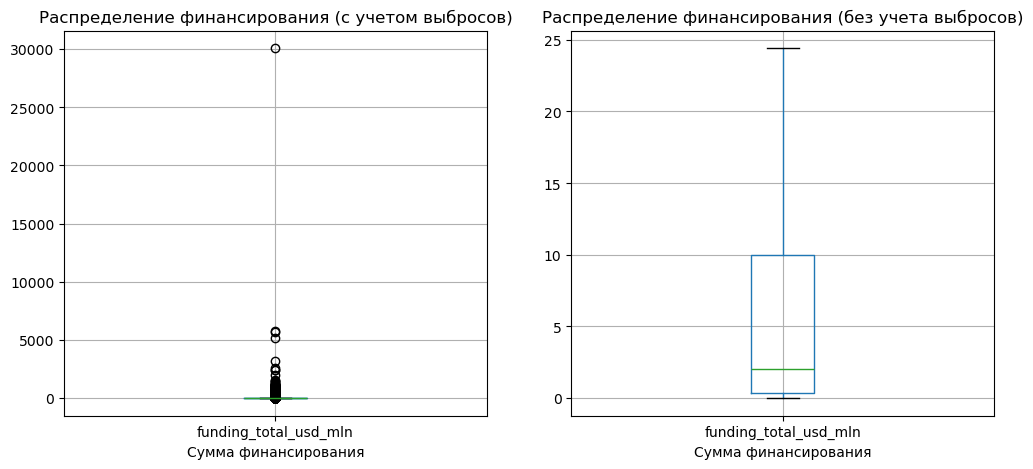

In [42]:
#Построим ящик с усами для массового сегмента
df_masm = df_main[(df_main['market'] != 'mid') & (df_main['market'] != 'niche')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Первый боксплот с учетом выбросов
boxplot1 = df_masm.boxplot(column='funding_total_usd_mln', ax=ax1)
ax1.set_title('Распределение финансирования (с учетом выбросов)')
ax1.set_xlabel('Сумма финансирования')

# Второй боксплот без выбросов без учета выбросов
boxplot2 = df_masm.boxplot(column='funding_total_usd_mln', showfliers=False, ax=ax2)
ax2.set_title('Распределение финансирования (без учета выбросов)')
ax2.set_xlabel('Сумма финансирования')

plt.show()

**Интепретация результатов для массового сегмента:**
- Разброс средних значений финансирования от 0,1 млн до 10 млн. 
- Медиана (линия внутри ящика) смещена ближе к нижнему краю, что указывать на асимметрию в данных. Мадиана равна 2 млн.
- Усы длинные, и это указывает на большой диапазон финансирования, включая как очень низкие, так и очень высокие значения. До 25 млн.
- Выбросы (точки за пределами усов) - значения, которые значительно отличаются от других данных и доходят до 30 млрд.

**Определим компании с аномальным объёмом общего финансирования — используя метод IQR отдельно по каждому сегменту. 
Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.**

На прошлых этапах, уже были опеределены срезы данных, содержащие данные данные по сегментам:
* `df_masm` - для массового сегмента
* `df_mid` - для среднего сегмента
* `df_niche` - для нишевого сегмента
На основе этих данных, используя метод IQR приведем расчеты по каждому сегменту:

In [43]:
# Определяем пороги для выбросов массового сегмента
# Так как Q1 изначально близка к 0, а диапазон выбросов Q1 - 1.5 * IQR будет отрицательным, 
# а отрицательного финансирования быть не может, то нас интересует только верхняя граница  Q3 + 1.5 * IQR

# Рассчитываем IQR для массового сегмента
Q1 = df_masm['funding_total_usd_mln'].quantile(0.25)
Q3 = df_masm['funding_total_usd_mln'].quantile(0.75)
IQR = Q3 - Q1
masm_bound = Q3 + 1.5 * IQR
# Рассчитываем IQR для среднего сегмента
Q1 = df_mid['funding_total_usd_mln'].quantile(0.25)
Q3 = df_mid['funding_total_usd_mln'].quantile(0.75)
IQR = Q3 - Q1
mid_bound = Q3 + 1.5 * IQR
# Рассчитываем IQR для нишего сегмента
Q1 = df_niche['funding_total_usd_mln'].quantile(0.25)
Q3 = df_niche['funding_total_usd_mln'].quantile(0.75)
IQR = Q3 - Q1
niche_bound = Q3 + 1.5 * IQR

print(masm_bound)
print(mid_bound)
print(niche_bound)

24.4375
19.25
13.244318750000001


In [44]:
# Посчитаем, сколько всего компаний в каждом сегменте в market
common_table = df_main.pivot_table(
    values='name',
    index='market',
    aggfunc='count'
)

In [45]:
# Определим компании с аномальным объёмом общего финансирования из массового сегменат:
df_masm_abnormal = df_masm[df_masm['funding_total_usd_mln'] > masm_bound]
masm_counts = df_masm_abnormal['market'].value_counts()

# Разделим кол-во компаний с аномальным объёмом общего финансирования на общее число компаний
# в разрезе каждого сегмента в market
top_mass_abnormal = masm_counts.div(common_table['name'], axis=0)

top_mass_abnormal = top_mass_abnormal.sort_values(ascending=False)
top_mass_abnormal=top_mass_abnormal*100

# Преобразуем в датафрейм
top_mass_abnormal = top_mass_abnormal.reset_index()
top_mass_abnormal.columns = ['Сементы рынка', 'Количество']

In [46]:
# Определим компании с аномальным объёмом общего финансирования из серднего сегменат:
df_mid_abnormal = df_mid[df_mid['funding_total_usd_mln'] > mid_bound]
mid_counts = df_mid_abnormal['market'].value_counts()

# Разделим кол-во компаний с аномальным объёмом общего финансирования на общее число компаний
# в разрезе каждого сегмента в market
top_mid_abnormal = mid_counts.div(common_table['name'], axis=0)

top_mid_abnormal = top_mid_abnormal.sort_values(ascending=False)
top_mid_abnormal=top_mid_abnormal*100

# Преобразуем в датафрейм
top_mid_abnormal = top_mid_abnormal.reset_index()
top_mid_abnormal.columns = ['Сементы рынка', 'Количество']

In [47]:
# Определим компании с аномальным объёмом общего финансирования из нишего сегменат:
df_niche_abnormal = df_niche[df_niche['funding_total_usd_mln'] > niche_bound]
niche_counts = df_niche_abnormal['market'].value_counts()

# Разделим кол-во компаний с аномальным объёмом общего финансирования на общее число компаний
# в разрезе каждого сегмента в market
top_niche_abnormal = niche_counts.div(common_table['name'], axis=0)

top_niche_abnormal = top_niche_abnormal.sort_values(ascending=False)
top_niche_abnormal=top_niche_abnormal*100

# Преобразуем в датафрейм
top_niche_abnormal = top_niche_abnormal.reset_index()
top_niche_abnormal.columns = ['Сементы рынка', 'Количество']

In [48]:
print('Количество компаний нишего сегмента с аномальным финансированием:')
top_niche_abnormal.round(2).head(1)

Количество компаний нишего сегмента с аномальным финансированием:


,Сементы рынка,Количество
0,niche,15.9


In [49]:
print('Количество компаний среднего сегмента с аномальным финансированием:')
top_mid_abnormal.round(2).head(1)

Количество компаний среднего сегмента с аномальным финансированием:


,Сементы рынка,Количество
0,mid,14.48


In [50]:
print('Топ-10 компаний массового сегмента с анамальным финансированием:')
top_mass_abnormal.round(2).head(10)

Топ-10 компаний массового сегмента с анамальным финансированием:


,Сементы рынка,Количество
0,semiconductors,32.23
1,clean technology,27.63
2,health care,27.00
3,web hosting,26.18
4,technology,24.79
5,biotechnology,23.07
6,security,17.11
7,cloud computing,16.45
8,enterprise software,16.08
9,finance,15.34


In [51]:
count_masm_abnormal = df_masm_abnormal.shape[0]
count_df_masm = df_masm.shape[0]
mass_abnormal_share = count_masm_abnormal / count_df_masm * 100
print('Количество компаний массового сегмента с аномальным финансированием:', round(mass_abnormal_share, 2))

Количество компаний массового сегмента с аномальным финансированием: 12.92


**<p style="color: black; background-color: orange;">Вывод по работае с выбросами:</p>**
- Были проанализированы периоды и размеры средств, которые предоставлялись компаниям 
- По данным из `funding_total_usd` графическим образом оценили, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. 
- Найдены интервалы, в которых лежат типичные значения финансирования.
- Используя метод IQR, определены компании с аномальным объёмом общего финансирования отдельно по каждому сегменту: `df_masm_abnormal`, `df_mid_abnormal`, `df_niche_abnormal`.
- Определины сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведен топ таких сегментов:
  
      - для нишего сегмента 15,9% компаний имеют аномальное финансирование
      - для среднего сегмента 14.48% компаний имеют аномальное финансирование
      - для масового сегмента характерно, что 12.92% компаний имеют аномальное финансирование, а именно: `semiconductors` 32,23%, `clean technology` 27.63%, `health care` 27.00%.

**Наибольшее аномальное финансирование получены компаниями из массового сегмента из таких сфер, как: `biotechnology`, `software`, `clean technology`, `health care`.**

### Определим границы рассматриваемого периода, отбросив аномалии

- Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год.
- Исключим из датасета компании, которые ранее посчитали получившими аномальное финансирование.
- Исключив аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях: получившие финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Найдем min и max по данным `first_funding_at` и `last_funding_at`

In [52]:
min_value1 = df_main['first_funding_at'].min()
max_value1 = df_main['first_funding_at'].max()
min_value2 = df_main['last_funding_at'].min()
max_value2 = df_main['last_funding_at'].max()
print('Данные по first_funding_at:')
print(f'Дата самого раннего первого финансирования:', min_value1.strftime('%d-%m-%Y'))
print(f'Дата самого позднего первого финансирования:', max_value1.strftime('%d-%m-%Y'))
print('')
print('Данные по last_funding_at:')

print(f'Дата самого раннего последнего финансирования:', min_value2.strftime('%d-%m-%Y'))
print(f'Дата самого позднего последнего финансирования:', max_value2.strftime('%d-%m-%Y'))

Данные по first_funding_at:
Дата самого раннего первого финансирования: 01-09-1921
Дата самого позднего первого финансирования: 31-12-2014

Данные по last_funding_at:
Дата самого раннего последнего финансирования: 01-09-1921
Дата самого позднего последнего финансирования: 31-12-2014


In [53]:
# Извлекаем даты за 2014 год
dates_2014 = df_main[(df_main['last_funding_at'].dt.year == 2014)]

# Данные по каждому месяцу для first_funding_at
monthly_counts_first = dates_2014.groupby(dates_2014['first_funding_at'].dt.month).size()
print("\nКоличество записей по месяцам (first_funding_at / дата первого финансирования):")
print(monthly_counts_first)

# Данные по каждому месяцу для last_funding_at
monthly_counts_last = dates_2014.groupby(dates_2014['last_funding_at'].dt.month).size()
print("\nКоличество записей по месяцам (last_funding_at / дата последнего финансирования):")
print(monthly_counts_first)


Количество записей по месяцам (first_funding_at / дата первого финансирования):
first_funding_at
1.0     1482
2.0      951
3.0     1092
4.0     1007
5.0      957
6.0     1122
7.0     1099
8.0      957
9.0     1011
10.0     991
11.0     762
12.0     481
dtype: int64

Количество записей по месяцам (last_funding_at / дата последнего финансирования):
first_funding_at
1.0     1482
2.0      951
3.0     1092
4.0     1007
5.0      957
6.0     1122
7.0     1099
8.0      957
9.0     1011
10.0     991
11.0     762
12.0     481
dtype: int64


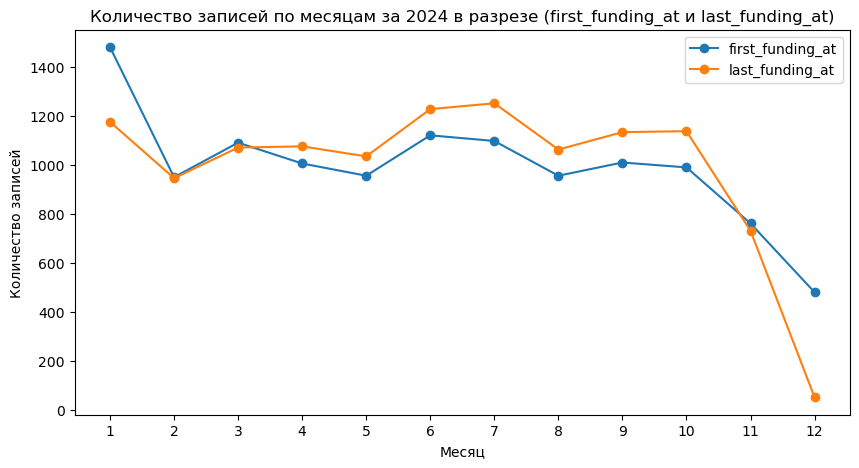

In [54]:
# Создаём график
plt.figure(figsize=(10, 5))
plt.plot(monthly_counts_first, label='first_funding_at', marker='o')
plt.plot(monthly_counts_last, label='last_funding_at', marker='o')

# Добавляем легенду и заголовки
plt.legend()
plt.xlabel('Месяц')
plt.ylabel('Количество записей')
plt.title('Количество записей по месяцам за 2024 в разрезе (first_funding_at и last_funding_at)')
plt.xticks(range(1, 13))

plt.show()


**Вывод: у нас есть данные почти за полный 2014.**

**Количество данных за 11 и 12 месяца года меньше, по сравнению с тем, сколько данных было в остальные периоды.**

Исключим из датасета компании, которые ранее посчитали получившими аномальное финансирование:

In [55]:
# Сравнивая по колонке key, удалим из df_main общие данные c df_masm_abnormal, df_mid_abnormal, df_niche_abnormal
df_main = df_main[~df_main['key'].isin(df_masm_abnormal['key'])]
df_main = df_main[~df_main['key'].isin(df_mid_abnormal['key'])]
df_main = df_main[~df_main['key'].isin(df_niche_abnormal['key'])]

Оставим в датасете данные только о компаниях, получивших финансирование в годы, когда было зафиксировано 50 или более раундов финансирования:

In [56]:
# Создаем новый столбец 'year_50', в который записываем год из столбца 'mid_funding_at'
df_main['year_50'] = df_main['mid_funding_at'].dt.strftime('%Y')

# Группируем данные по столбцу 'year_50' и суммируем значения из столбца 'funding_rounds' для каждой группы
group = df_main.groupby('year_50')['funding_rounds'].sum().reset_index()

# Фильтруем данные, оставляя только те строки, где сумма 'funding_rounds' больше или равна 50
rounds_over_50 = group[group['funding_rounds'] >= 50]

df_main = df_main[df_main['year_50'].isin(rounds_over_50['year_50'])]

**<p style="color: black; background-color: orange;">Вывод по определении границы рассматриваемого периода, отбрасывании аномалии:</p>**
- Проверили, что нам предоставили полные данные за 2014 год.
- Исключили из датасета компании, которые ранее посчитали получившими аномальное финансирование.
- На основе столбцов `mid_funding_at` и `funding_rounds` оставили в датасете данные только о компаниях, получивших финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

### Анализ типов финансирования по объёму и популярности

- На основании столбцов `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding` постром график, который покажет, какие типы финансирования в сумме привлекли больше всего денег.
- Постром график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.
- Сравним графики и выделим:
    -  часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами;
    -  встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.
- Постройм график суммарных объёмов возвратов от разных типов финансирования за весь период на основе датасета `df_second`.

Рассчитываем общую сумму для каждого типа финансирования
venture                 106238.45
seed                      9583.94
debt_financing            5742.58
private_equity            3188.56
angel                     2602.86
undisclosed               2185.70
grant                     1897.64
post_ipo_equity            968.31
convertible_note           496.23
equity_crowdfunding        278.72
product_crowdfunding       212.94
post_ipo_debt              147.81
secondary_market            45.29
dtype: float64


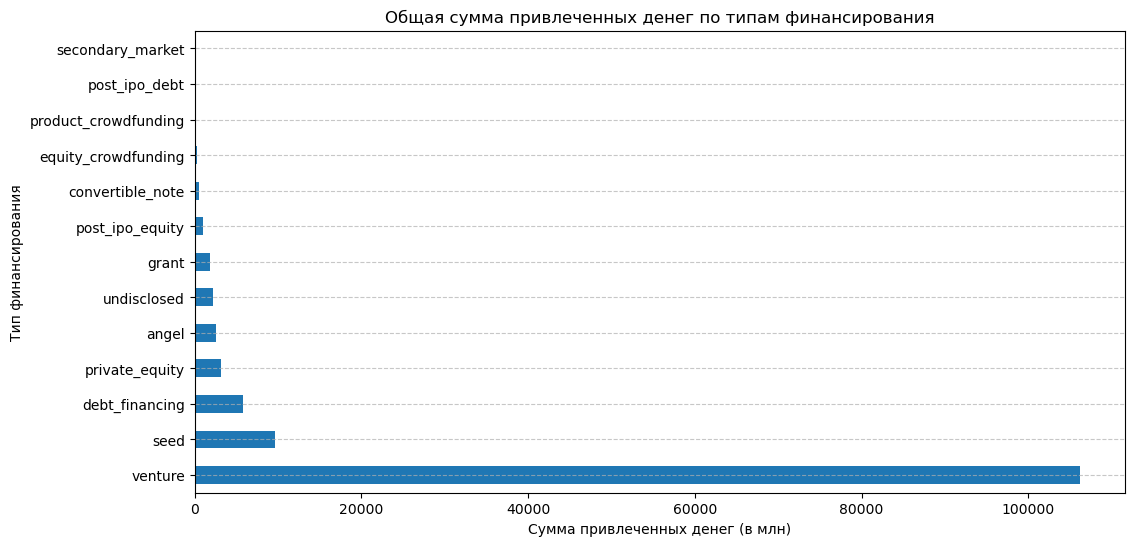

In [57]:
# Рассчитываем общую сумму для каждого типа финансирования
total_funding = df_main[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
                         'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
                         'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()
total_funding = total_funding / 1000000
total_funding=total_funding.sort_values(ascending=False)
print('Рассчитываем общую сумму для каждого типа финансирования')
print(total_funding.round(2))

# Создаем график
plt.figure(figsize=(12, 6))
total_funding.plot(kind='barh')
plt.title('Общая сумма привлеченных денег по типам финансирования')
plt.xlabel('Сумма привлеченных денег (в млн)')
plt.ylabel('Тип финансирования')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


**Топ-3 самые крупные суммы были профинансированы способами: `venture`, `seed`, `debt_financing`.**

Постром график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.


venture                 18693
seed                    13473
debt_financing           3059
angel                    2987
grant                    1000
undisclosed               830
private_equity            588
equity_crowdfunding       520
convertible_note          507
product_crowdfunding      208
post_ipo_equity           135
post_ipo_debt              23
secondary_market            7
dtype: int64


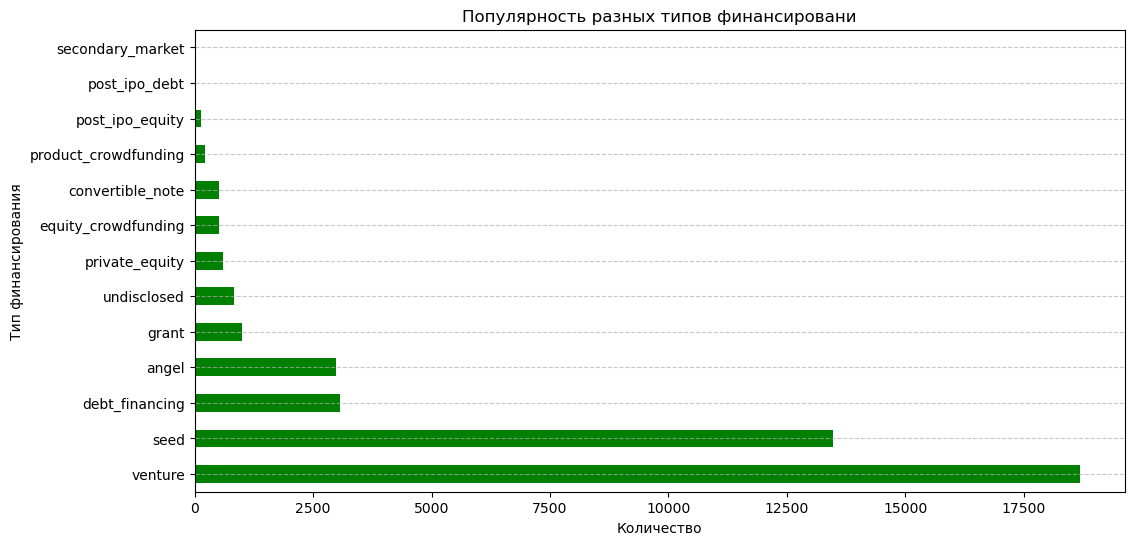

In [58]:
# удалим 0, так как они могут помешать подсчитать количество
columns = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
                      'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
                      'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
df_main[columns] = df_main[columns] / 1000000
# Заменяем 0 на пропуски (None)
df_main[columns] = df_main[columns].replace({0: None})

total_count = df_main[columns].count().sort_values(ascending=False)
print(total_count)

# Создаем график
plt.figure(figsize=(12, 6))
total_count.plot(kind='barh', color='green')
plt.title('Популярность разных типов финансировани')
plt.xlabel('Количество')
plt.ylabel('Тип финансирования')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Топ-3 самые популярные способа привлечения финансирования: `venture`, `seed`, `debt_financing`.**

Сравним графики и выделим:
- часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами;
- встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

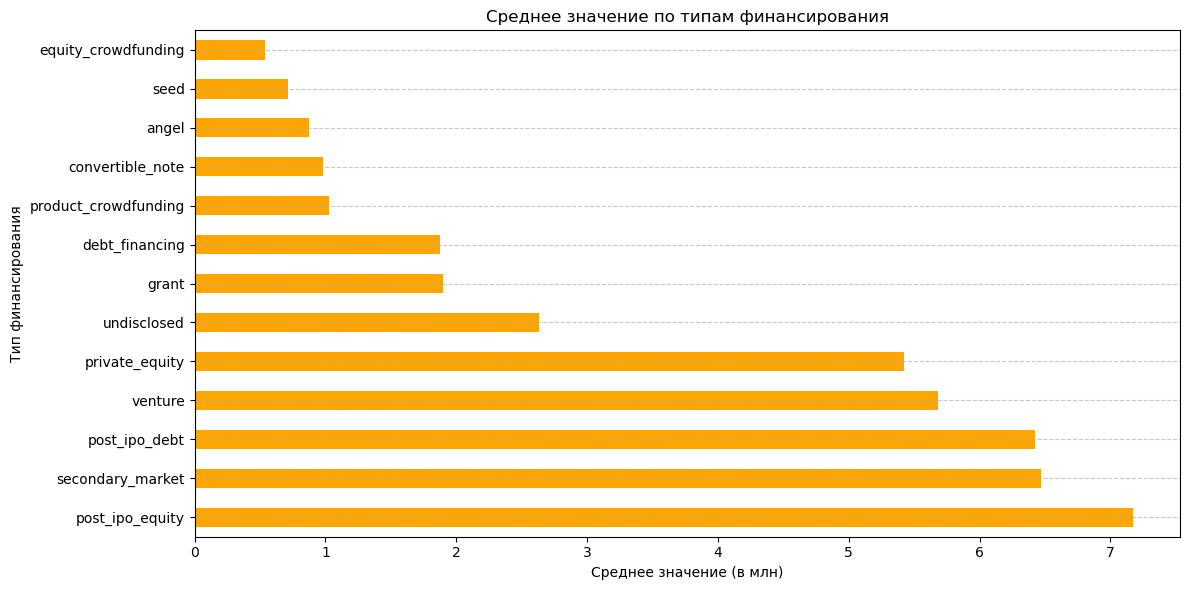

In [59]:
# Подсчитываем среднее значение для каждого из указанных столбцов
mean_values = df_main[columns].mean().sort_values(ascending=False)

# Создаем график
plt.figure(figsize=(12, 6))
mean_values.plot(kind='barh', color='orange')
plt.title('Среднее значение по типам финансирования')
plt.xlabel('Среднее значение (в млн)')
plt.ylabel('Тип финансирования')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [60]:
# Создаём DataFrame с необходимыми данными
df_table = pd.DataFrame({
    'Сумма': total_funding,
    'Количество': total_count,
    'Ср. сумма фин-ия': mean_values
})
# Сортируем по столбцу 'Ср сумма фин-ия'
df_table = df_table.sort_values(by='Ср. сумма фин-ия', ascending=False)  # ascending=False для сортировки по убыванию

df_table = df_table.style.background_gradient(cmap='viridis', axis=0).format({
    'Сумма': '{:,.2f}'.format,
    'Количество': '{:,.2f}'.format,
    'Ср. сумма фин-ия': '{:,.2f}'.format})

# Выводим таблицу
display(df_table)

,Сумма,Количество,Ср. сумма фин-ия
post_ipo_equity,968.31,135.00,7.17
secondary_market,45.29,7.00,6.47
post_ipo_debt,147.81,23.00,6.43
venture,"106,238.45","18,693.00",5.68
private_equity,"3,188.56",588.00,5.42
undisclosed,"2,185.70",830.00,2.63
grant,"1,897.64","1,000.00",1.90
debt_financing,"5,742.58","3,059.00",1.88
product_crowdfunding,212.94,208.00,1.02
convertible_note,496.23,507.00,0.98


**Отсортировав данные по средней сумме финансирования, наглядно видно:**
- Тип `secondary_market` встречался 7 раз, но в среднем привлекал по 6,47 млн, что почти максимальная сумма разового среднего финансирования;
- Типы `seed` и `angel` часто встречались, но в среднем привлекали по 0,71 илн и 0,98 млн, что составляет в среднем минимальный объем финансирования.
- чаще всего и высокое значение среднего финансирования имеет тип `venture`.

Постройм график суммарных объёмов возвратов от разных типов финансирования за весь период на основе датасета `df_second`.

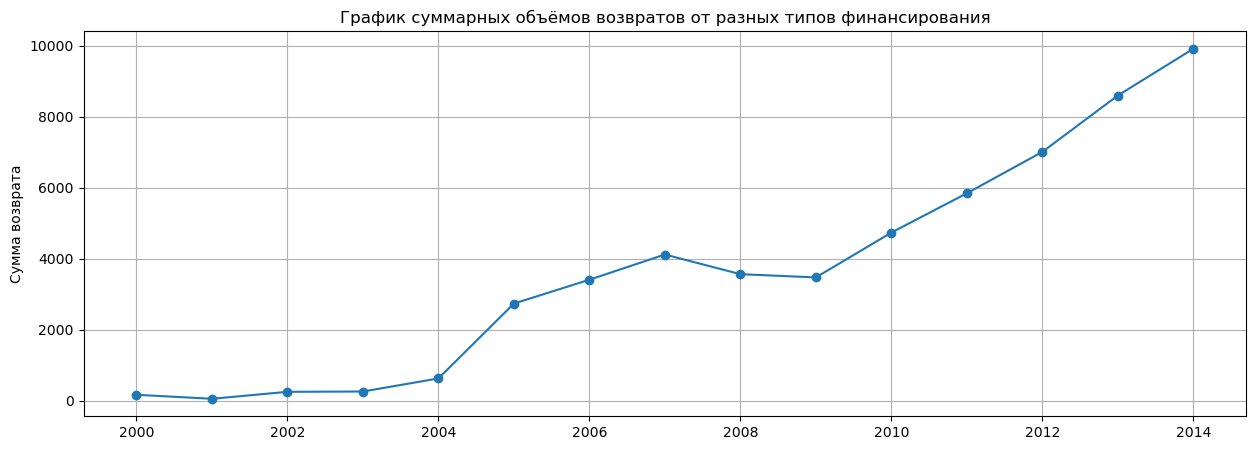

In [61]:
df_second['total'] = df_second[['seed', 
                                'venture', 
                                'equity_crowdfunding', 
                                'undisclosed', 
                                'convertible_note', 
                                'debt_financing', 
                                'angel', 'grant', 
                                'private_equity', 
                                'post_ipo_equity', 
                                'post_ipo_debt', 
                                'secondary_market', 
                                'product_crowdfunding']].sum(axis=1)
# Построение графика
plt.figure(figsize=(15, 5))
plt.plot(df_second.index, df_second['total'], marker='o')
plt.title('График суммарных объёмов возвратов от разных типов финансирования')
plt.xlabel('')
plt.ylabel('Сумма возврата')
plt.grid()
plt.show()

**<p style="color: black; background-color: orange;">Вывод по анализу типов финансирования по объёму и популярности:</p>**
- На основании столбцов `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding` проведен анализ, какие типы финансирования в сумме привлекли больше всего денег, какие типы финансирования чаще всего используются компаниями и выявлены: 
    -  часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами;
    -  встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.
- Построен график суммарных объёмов возвратов от разных типов финансирования за весь период на основе датасета `df_second`.

## Анализ динамики

### Динамика предоставления финансирования по годам

- Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.
- На основе получившейся таблицы построим графики, отражающие:
    - динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;
    - динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?
* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [62]:
df_main['average_per_round'] = df_main['funding_total_usd_mln'] / df_main['funding_rounds']

In [63]:
df_main['year_50'] = df_main['year_50'].astype(int)

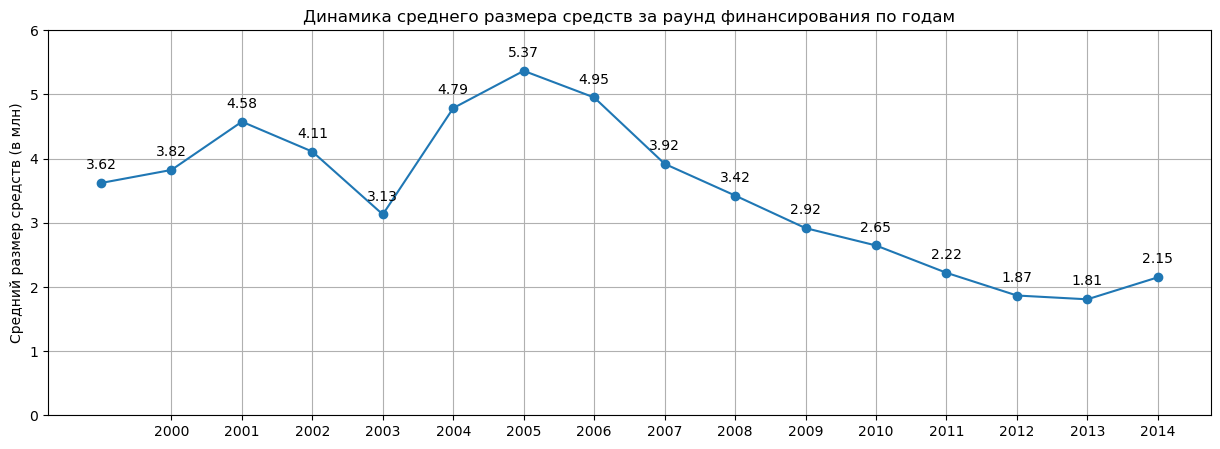

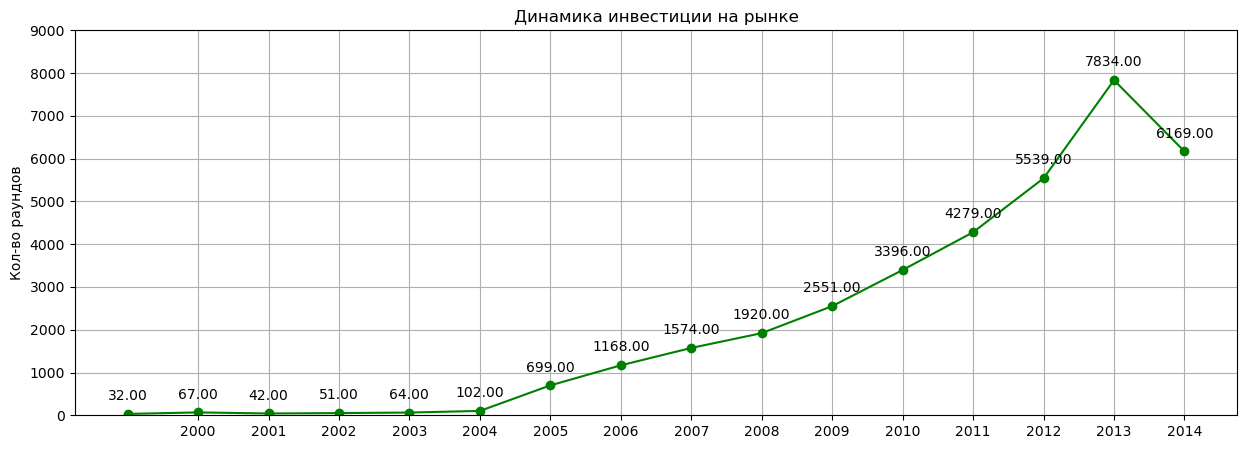

In [64]:
mean_values = df_main.groupby('year_50')['average_per_round'].mean()

plt.figure(figsize=(15, 5))
plt.plot(mean_values.index, mean_values, marker='o', linestyle='-')
plt.title('Динамика среднего размера средств за раунд финансирования по годам')
plt.xlabel('')
plt.ylabel('Средний размер средств (в млн)')
plt.grid()
plt.xticks(range(2000, 2015))
# Устанавливаем минимальные и максимальные значения для оси Y, чтобы все подписи были видны
plt.ylim(0, 6)

# Делаем подписи данных
for i, value in enumerate(mean_values):
    plt.annotate(f"{value:.2f}", (mean_values.index[i], value),
                 textcoords="offset points", xytext=(0, 10), ha='center')

plt.show()

coint_values = df_main.groupby('year_50')['average_per_round'].count()

plt.figure(figsize=(15, 5))
plt.plot(coint_values.index, coint_values, marker='o', linestyle='-', color='green')
plt.title('Динамика инвестиции на рынке')
plt.xlabel('')
plt.ylabel('Кол-во раундов')
plt.grid()
plt.xticks(range(2000, 2015))

# Устанавливаем минимальные и максимальные значения для оси Y, чтобы все подписи были видны
plt.ylim(0, 9000)

# Делаем подписи данных
for i, value in enumerate(coint_values):
    plt.annotate(f"{value:.2f}", (coint_values.index[i], value),
                 textcoords="offset points", xytext=(0, 10), ha='center')


**<p style="color: black; background-color: orange;">Графики показывают:</p>**


- С ростом активности на рынке, средним объем финансирования за рауинд постепенно снижался.
- В 2005 году типичный размер средств, собранных в рамках одного раунда, был максимальным и составлял 5,37 млн.
- В 2014 году количество рауиндов снизилось по сравнению с 2013, и а сумма средств наоборот начала расти.

**Скорее всего в 2014 году Мы видим новый тренд на по уменьшению количества раундов финансирования при просте инвестиций.**

### Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов
Рассматривая только массовые сегменты:
- Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка.
- Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.
- Отразим на графике, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных. 
- На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [65]:
filtered_df = df_main[~df_main['market'].isin(['niche', 'mid'])]

table2 = filtered_df.pivot_table(
    values='funding_total_usd_mln',
    index='year_50',
    columns='market',
    aggfunc='sum',
    fill_value=0
)

# Добавляем столбец для общего финансирования по каждому году
table2['Total'] = table2.sum(axis=1)

# Переворачиваем таблицу
table3 = table2.transpose()

# Применяем стили
table3 = table3.style.background_gradient(cmap='viridis', axis=1 )
table3 = table3.format("{:.0f}")

display(table3)


year_50,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,,
advertising,0,14,9,24,10,6,102,223,504,545,513,605,332,496,525,183
analytics,11,15,0,8,4,3,79,140,49,156,141,229,393,514,623,151
apps,0,0,0,0,0,0,0,1,20,21,53,68,24,80,79,147
automotive,0,0,0,0,5,0,22,13,38,59,21,18,76,36,118,69
big data,0,0,0,0,0,0,0,0,8,2,1,57,60,149,115,103
biotechnology,0,0,0,0,42,45,291,451,776,739,1897,2161,2263,2391,3182,1479
clean technology,0,0,0,0,2,19,19,26,229,1203,672,600,667,566,644,325
cloud computing,0,12,0,0,0,0,0,10,20,44,52,9,73,74,85,73
consulting,0,4,0,0,0,0,65,68,104,19,122,118,168,107,154,86


In [66]:
# Извлекаем данные за 2013 и 2014 годы до транспонирования
data_2013 = table2.loc[2013]
data_2014 = table2.loc[2014]

# Сравниваем значения и выбираем сегменты с ростом
growing_markets = data_2014[data_2014 > data_2013]
growing_markets = growing_markets.round(1)

print("Сегменты с ростом финансирования в 2014 году по сравнению с 2013:")
print(growing_markets.sort_values(ascending=False))


Сегменты с ростом финансирования в 2014 году по сравнению с 2013:
market
real estate    193.5
medical        175.2
technology     172.0
saas           152.8
apps           147.3
internet       130.7
startups        75.5
video           75.3
nonprofits      72.3
sports          58.5
Name: 2014, dtype: float64


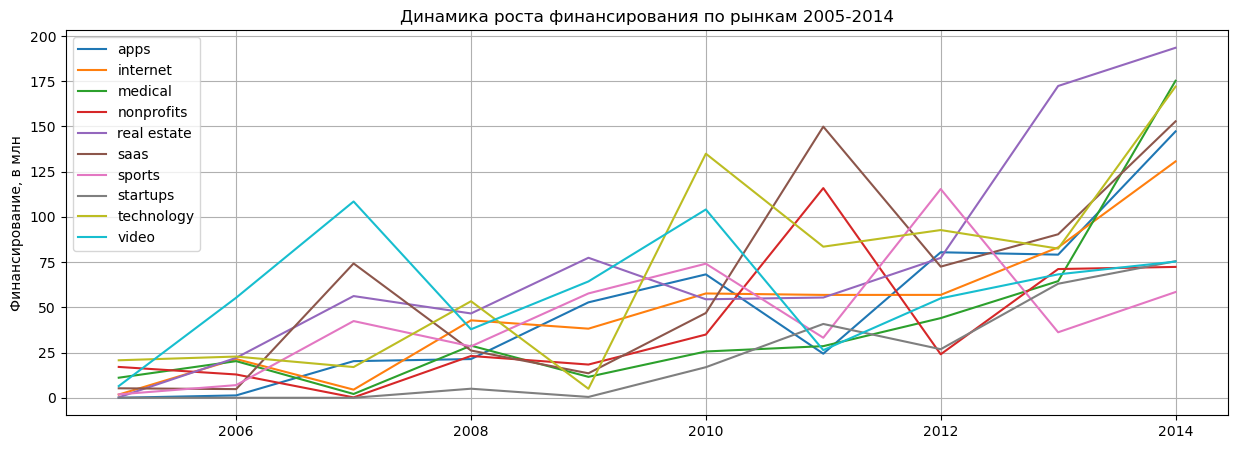

In [67]:
# Фильтруем table2, оставляя только строки с годами начиная с 2005
filtered_table2 = table2.loc[table2.index >= 2005, :]
# Фильтруем оставляя только столбцы (markets), которые есть в growing_markets
filtered_table2 = filtered_table2.loc[:, filtered_table2.columns.isin(growing_markets.index)]

plt.figure(figsize=(15, 5))

for market in filtered_table2.columns:
    plt.plot(filtered_table2.index, filtered_table2[market], marker='', label=market)

plt.title('Динамика роста финансирования по рынкам 2005-2014')
plt.xlabel('')
plt.ylabel('Финансирование, в млн')
plt.legend(loc='upper left')
plt.grid()
plt.show()


**<p style="color: black; background-color: orange;">Вывод по анаилизу динамики финансирования по массовым сегментам рынка для растущих в 2014 году сегментов:</p>**
Рассматривая только массовые сегменты:
- Составили сводную таблицу, в которой указали суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка.
- Отобрали только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.
- Отобразили на графике, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных (данные взяты начиная с 2005, так как с 1999 по 2004 было всего 2021 раунд финансирования, а в 2005 есть информация о 4239, что наглядно видно из предыдущей таблицы). 

**Не основе полученных данных можно выделить сегменты рынка: `real estate`, `medical`, `technology`, как сегменты с самым выросшим финансирование в 2014 году.**

### Годовая динамика доли возвращённых средств по типам финансирования

Проанализируем:
- Какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам.
- Для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных.
- Аномальные значения, неадекватные выбросы, заменим на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [68]:
filtered_df = df_main[df_main['year_50'] >= 2000]

#сводбная таблица по объемам финансирования 2000-2014
table_in = filtered_df.pivot_table(
    values=['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
            'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
            'post_ipo_debt', 'secondary_market', 'product_crowdfunding'],
    index='year_50',
    aggfunc='sum'
)
table_in = table_in.rename_axis(index='year')

#сводбная таблица по объемам возвращенных средств 2000-2014
table_out = df_second.pivot_table(
    values=['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
            'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
            'post_ipo_debt', 'secondary_market', 'product_crowdfunding'],
    index='year',
    aggfunc='sum'
)
# Вычисляем долю возвращённого финансирования
table_share = table_out / (table_in + 1e-60)
table_share = table_share.where(table_share <= 4, np.nan)
table_share_trans = table_share.transpose()


table_share_style = table_share_trans.style.background_gradient(cmap='RdYlGn', axis=0)
table_share_style = table_share_style.format("{:.2%}")  # Изменяем формат на процентный

display(table_share_style)

year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
angel,24.65%,118.00%,113.67%,36.78%,83.35%,49.37%,65.61%,76.82%,40.13%,58.07%,61.71%,42.16%,48.08%,51.85%,105.91%
convertible_note,0.00%,nan%,nan%,nan%,nan%,nan%,15.07%,28.92%,11.14%,6.60%,7.33%,6.37%,4.56%,4.92%,8.56%
debt_financing,123.71%,54.42%,23.90%,103.81%,64.47%,55.08%,97.96%,79.60%,150.33%,52.13%,74.01%,73.70%,74.13%,66.87%,152.24%
equity_crowdfunding,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,20.36%,nan%,nan%,8.78%,4.79%,9.70%,2.92%,1.80%,0.62%
grant,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
post_ipo_debt,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,98.06%,162.72%,281.94%,30.66%
post_ipo_equity,27.11%,nan%,113.33%,nan%,nan%,73.19%,nan%,203.00%,nan%,313.53%,nan%,293.38%,201.85%,115.48%,44.93%
private_equity,0.00%,0.00%,9.18%,nan%,nan%,48.00%,55.45%,121.76%,280.11%,156.64%,152.99%,183.10%,102.34%,77.93%,134.40%
product_crowdfunding,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,6.60%,6.86%,3.32%,1.29%,0.35%,0.89%
secondary_market,2.59%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,0.62%,19.78%,1.28%,nan%,nan%,21.21%


Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

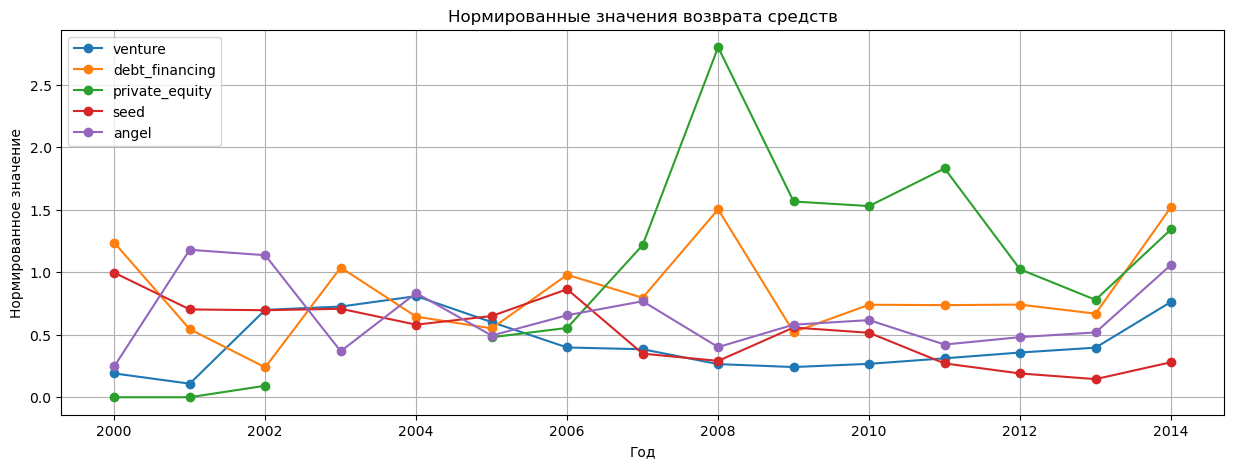

In [69]:
selected_columns = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
filtered_table_share = table_share[selected_columns]

# Строим график
plt.figure(figsize=(15, 5))
for column in filtered_table_share:
    plt.plot(filtered_table_share.index, filtered_table_share[column], marker='o', label=column)

plt.title('Нормированные значения возврата средств')
plt.xlabel('Год')
plt.ylabel('Нормированное значение')
plt.legend(loc='upper left')
plt.grid()
plt.show()

**<p style="color: black; background-color: orange;">Вывод по годовой динамике доли возвращённых средств по типам финансирования:</p>**
Был проведен анализ:
- Какая часть вложенных или выданных денег со временем возвращается обратно инвесторам и финансистам.
- Для каждого года и каждого вида финансирования рассчитали нормированные значения возврата средств.
- Аномальные значения, неадекватные выбросы, заменим на пропуски.
- Построили график, на котором отобразили нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

**По итогам анализа можно сделать выводы:**
- Наибольший возврат средств характерен для типов `private_equity`, `debt_financing`, `angel`
- Возврат средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel` немного меняется по годам, но в среднем debt_financing имеет больший объем возврата, чем у остальных.
- Данные для `private_equity` имеют большую волатильность и не ясно, тут дело в ошибке данных, или она действительно такая и есть.


## Итоговый вывод и рекомендации

Подведите итоги проекта:
* Основная работа по предобработке была проведена с датасетом `df_main`. Был проведен поиск и исправление ошибок, проверены и выявлены дубликаты, типы данных приведены удобным для работы. Никакие критичеси важные данные не были потеряны и можно присутпить к целям и задачам работы.
* По группам сроков финансирования: 58,9% всех компаний, это компании с единичным финансированием, при этом они получили примерно только 30% об общего объема финансирования.
- Только 10,8% всех компаний финансировались более 1 года, получив 30% всех финансовых средств.
- Больше всего финансирования (40%) получили компании с финансированием до 1 года.
- На основе информации о сегменте рынка компаний в столбце `market` рассчитали, как часто в датасете встречается: `Массовый сегмент`,  `Средний сегмент`, `Нишевый сегмент`.
- Рассчитали, сколько сегментов попадает в каждую из категорий.
- Построили график распределения количества компаний в сегментах.
- Оставили в столбце market только массовые сегменты. Для остальных сегментов заменили значения на заглушки — niche для нишевых и mid для средних.
- Были проанализированы периоды и размеры средств, которые предоставлялись компаниям 
- По данным из `funding_total_usd` графическим образом оценили, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. 
- Найдены интервалы, в которых лежат типичные значения финансирования.
- Используя метод IQR, определены компании с аномальным объёмом общего финансирования отдельно по каждому сегменту: `df_masm_abnormal`, `df_mid_abnormal`, `df_niche_abnormal`.
- Определины сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведен топ таких сегментов.
- Проверили, что нам предоставили полные данные за 2014 год.
- Исключили из датасета компании, которые ранее посчитали получившими аномальное финансирование.
- На основе столбцов `mid_funding_at` и `funding_rounds` оставили в датасете данные только о компаниях, получивших финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.
- На основании столбцов `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding` проведен анализ, какие типы финансирования в сумме привлекли больше всего денег, какие типы финансирования чаще всего используются компаниями и выявлены: 
    -  часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами;
    -  встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.
- Построен график суммарных объёмов возвратов от разных типов финансирования за весь период на основе датасета `df_second` и были получены ответы на следующие вопросы:
    - С ростом активности на рынке, средним объем финансирования за рауинд постепенно снижался.
    - В 2005 году типичный размер средств, собранных в рамках одного раунда, был максимальным и составлял 5,37 млн.
    - В 2014 году количество рауиндов снизилось по сравнению с 2013, и а сумма средств наоборот начала расти.
- Составили сводную таблицу, в которой указали суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка.
- Отобрали только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.
- Отобразили на графике, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных.
- Ответили на вопросы
    - Наибольший возврат средств характерен для типов `private_equity`, `debt_financing`, `angel`
    - Возврат средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel` немного меняется по годам, но в среднем debt_financing имеет больший объем возврата, чем у остальных.
    - Данные для `private_equity` имеют большую волатильность и не ясно, тут дело в ошибке данных, или она действительно такая и есть.

**Не основе полученных данных можно выделить сегменты рынка: `real estate`, `medical`, `technology`, как сегменты с самым выросшим финансирование в 2014 году.**

**Скорее всего в 2014 году Мы видим новый тренд на по уменьшению количества раундов финансирования при просте инвестиций.**

**Наибольшее аномальное финансирование получены компаниями из массового сегмента из таких сфер, как: `biotechnology`, `software`, `clean technology`, `health care`.**

**По итогу видно, что финансирование чаще получают компании из `Массовый сегмент`.**

**Рекомендации по инвестированию в 2015 году:**
* Стоит инвестировать в `real estate`, `medical`, `technology`;
* Типы финансирования `private_equity`, `debt_financing`, `angel`.